In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ['KERAS_BACKEND'] = 'tensorflow'
from keras.models import Sequential
from keras.layers import Dense, LSTM, Flatten, Conv2D
from sklearn.model_selection import KFold

2026-08-08 19:18:47.334041: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-08 19:18:47.345755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786213127.359357 1789169 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786213127.362741 1789169 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-08 19:18:47.381651: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Set font type to Arial
plt.rcParams['font.family'] = 'Arial'

In [3]:
def AA_hotencoding(variant):
    
    """
    
    AA_hotencoding takes an amino acid sequence 'variant' of an arbitrary length, 
    and returns a 20xlength one-hot encoding matrix 'onehot_encoded'.   
    
    """
       
    AAs = 'ARNDCQEGHILKMFPSTWYV'
    encoding_length = len(AAs)
    variant_length = len(variant)

    # Define a mapping of chars to integers
    char_to_int = dict((c, i) for i, c in enumerate(AAs))
    int_to_char = dict((i, c) for i, c in enumerate(AAs))

    # Encode input data 
    integer_encoded = [char_to_int[char] for i, char in enumerate(variant) if i <variant_length]
    
    # Start one-hot-encoding
    onehot_encoded = list()
    
    for value in integer_encoded:
        letter = [0 for _ in range(encoding_length)]
        letter[value] = 1
        onehot_encoded.append(letter)
                
    return onehot_encoded

def parent_model(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def dense_model(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=8))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def layered_model(L1=160):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L1, return_sequences=True))
    model.add(LSTM(L1, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def small_model(L1=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L1, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def large_model(L1=300):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L1, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def perceptron_model(L1=160):

    model = Sequential()
    model.add(Flatten(input_shape=(8, 20)))
    model.add(Dense(L1))
    model.add(Dense(L1))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def convolutional_model(L1=160):
    model = Sequential()
    # Add a Conv2D layer with filters that convolve along the height (8) while preserving the width (20)
    model.add(Conv2D(L1, (8, 1), activation='relu', input_shape=(8, 20, 1)))
    # Flatten the output to feed into Dense layers
    model.add(Flatten())
    # Output layer with a single unit for continuous output
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

In [4]:
# GOAL I would like to take the log2 of the average enrichment score

# Load the Excel file into a DataFrame
file_path = 'data/Excel/third_round/enrichment_score_with_amino_acid_sequence_threshold.xlsx' 
df = pd.read_excel(file_path)

# log2 transform the 'averaged_enrichment_score' column
df['log2_averaged_enrichment_score'] = df['averaged_enrichment_score'].apply(lambda x: np.log2(x))

display(df.head())

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score,log2_averaged_enrichment_score
0,LNHHFYYV,[0.1494201476168534],1,0.149420,-2.742553
1,FTHHSYAG,[0.2124630124952891],1,0.212463,-2.234716
2,AWHHYYYI,[0.2232907823937248],1,0.223291,-2.163004
3,LGLFSFIP,[0.2278196077861901],1,0.227820,-2.134036
4,WVHHSYAN,[0.2278196077861901],1,0.227820,-2.134036


In [5]:
# GOAL train test split
train_size = 1619
test_size = 202

# Split the data into training and test sets
train, test = np.split(df.sample(frac=1), [train_size])

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [6]:
# GOAL one hot encoding of the amino acid sequences

train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
train_y = np.asarray([score for score in train['log2_averaged_enrichment_score']])
test_x = np.asarray([AA_hotencoding(variant) for variant in test["amino_acid_sequence"]])
test_y = np.asarray([score for score in test['log2_averaged_enrichment_score']])

In [7]:
# Define the number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
# Perform cross-validation for each model
models = {
    'Dense(160,160,1)': perceptron_model,
    'LSTM(160,20)_Dense(1)': parent_model,
    'LSTM(160,160,160)_Dense(1)': layered_model,
    'LSTM(20)_Dense(1)': small_model,
    'LSTM(160,160,160)_Dense(1)': large_model,
    'LSTM(160,20)_Dense(8,1)' : dense_model,
    'Conv2D(160)_Dense(1)': convolutional_model
}

# Initialize dictionaries to store results
val_loss_results = {model_name: [] for model_name in models.keys()}
pearson_results = {model_name: [] for model_name in models.keys()}
train_loss_curves = {model_name: [] for model_name in models.keys()}
val_loss_curves = {model_name: [] for model_name in models.keys()}

In [9]:
for model_name, model_func in models.items():
    fold = 1
    fold_results = []
    for train_index, val_index in kf.split(train_x):
        print(f"Training fold {fold} for {model_name}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y[train_index], train_y[val_index]
        
        # Create the model
        model = model_func()
        
        # Train the model
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=500,
            verbose=0
        )

        # Store the per-epoch training/validation loss curves for this fold
        train_loss_curves[model_name].append(history.history['loss'])
        val_loss_curves[model_name].append(history.history['val_loss'])
        
        # Evaluate the model on the validation set
        val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

        # Store the results for the current model
        val_loss_results[model_name].append(val_loss)
        print(f"Val_loss for {model_name} {fold}: {val_loss}")
        y_pred = model.predict(X_val)
        y_pred = np.reshape(y_pred, (1,y_pred.shape[0]))[0]
        pearson_corr = np.corrcoef(y_val, y_pred)[0, 1]
        pearson_results[model_name].append(pearson_corr)
        print(f"Pearson for {model_name} {fold}: {pearson_results[model_name]}")
        
        fold += 1

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1786213131.427831 1789169 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Training fold 1 for Dense(160,160,1)...
Val_loss for Dense(160,160,1) 1: 0.39388787746429443
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Pearson for Dense(160,160,1) 1: [0.6220848805512311]
Training fold 2 for Dense(160,160,1)...
Val_loss for Dense(160,160,1) 2: 0.3605799973011017
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Pearson for Dense(160,160,1) 2: [0.6220848805512311, 0.5921350771255147]
Training fold 3 for Dense(160,160,1)...
Val_loss for Dense(160,160,1) 3: 0.42262253165245056
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Pearson for Dense(160,160,1) 3: [0.6220848805512311, 0.5921350771255147, 0.6380783907374913]
Training fold 4 for Dense(160,160,1)...
Val_loss for Dense(160,160,1) 4: 0.4324030876159668
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Pearson for Dense(160,160,1) 4: [0.6220848805512311, 0.5921350771255147, 0.6380783907374913, 0.580675171116363]
Training fold 5 for Dense(160,160,1)...
Val_loss for Dense(160,160,1) 5: 0.44842615723609924
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearso

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Val_loss for LSTM(160,20)_Dense(1) 1: 0.32711851596832275
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Pearson for LSTM(160,20)_Dense(1) 1: [0.6944865041090261]
Training fold 2 for LSTM(160,20)_Dense(1)...
Val_loss for LSTM(160,20)_Dense(1) 2: 0.32183709740638733
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Pearson for LSTM(160,20)_Dense(1) 2: [0.6944865041090261, 0.6329052184954115]
Training fold 3 for LSTM(160,20)_Dense(1)...
Val_loss for LSTM(160,20)_Dense(1) 3: 0.3927183151245117
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Pearson for LSTM(160,20)_Dense(1) 3: [0.6944865041090261, 0.6329052184954115, 0.6615407149954933]
Training fold 4 for LSTM(160,20)_Dense(1)...
Val_loss for LSTM(160,20)_Dense(1) 4: 0.3900388777256012
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Pearson for LSTM(160,20)_Dense(1) 4: [0.6944865041090261, 0.6329052184954115, 0.6615407149954933, 0.6185971421360374]
Training fold 5 for LSTM(160,20)_Dense(1)...
Val_loss for LSTM(160,20)_Dense(1) 5: 0.39586764574050903
11/11 ━━━━━━━━━━━━━━

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Val_loss for Conv2D(160)_Dense(1) 1: 0.35503238439559937
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Conv2D(160)_Dense(1) 1: [0.6599097169388277]
Training fold 2 for Conv2D(160)_Dense(1)...
Val_loss for Conv2D(160)_Dense(1) 2: 0.3110296130180359
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Conv2D(160)_Dense(1) 2: [0.6599097169388277, 0.6433222546628181]
Training fold 3 for Conv2D(160)_Dense(1)...
Val_loss for Conv2D(160)_Dense(1) 3: 0.3930308520793915
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for Conv2D(160)_Dense(1) 3: [0.6599097169388277, 0.6433222546628181, 0.6582969506794014]
Training fold 4 for Conv2D(160)_Dense(1)...
Val_loss for Conv2D(160)_Dense(1) 4: 0.37573617696762085
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for Conv2D(160)_Dense(1) 4: [0.6599097169388277, 0.6433222546628181, 0.6582969506794014, 0.6318162503124976]
Training fold 5 for Conv2D(160)_Dense(1)...
Val_loss for Conv2D(160)_Dense(1) 5: 0.41066041588783264
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

In [10]:
# Print the results
print("Cross-Validation Results:")
for model_name, val_loss in val_loss_results.items():
    print(f"{model_name}: {np.mean(val_loss)}")

Cross-Validation Results:
Dense(160,160,1): 0.41158393025398254
LSTM(160,20)_Dense(1): 0.36551609039306643
LSTM(160,160,160)_Dense(1): 0.36311662197113037
LSTM(20)_Dense(1): 0.39097853302955626
LSTM(160,20)_Dense(8,1): 0.35663962960243223
Conv2D(160)_Dense(1): 0.36909788846969604


/tmp/ipykernel_1789169/286601989.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1789169/286601989.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=22)


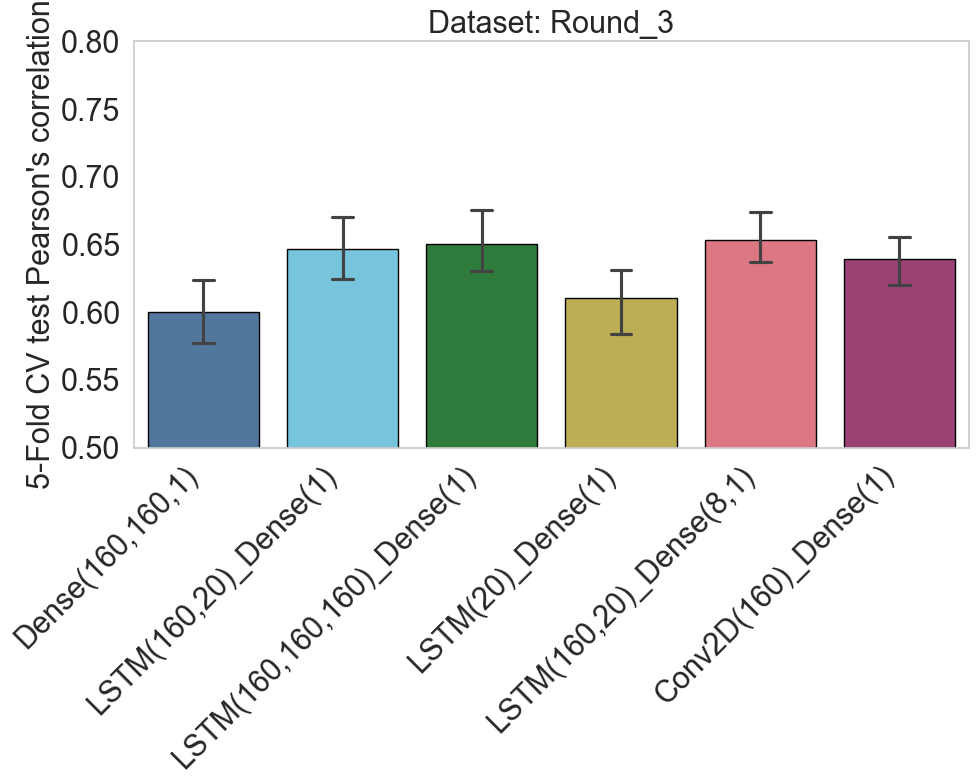

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Paul Tol's Notes color scheme
colors = ['#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

# Function to darken a color
def darken_color(color, amount=0.1):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(0, c[i] - amount) for i in range(3)])

darker_colors = [darken_color(color) for color in colors]

# Convert dict of lists into long-form DataFrame
rows = []
for model_name, corrs in pearson_results.items():
    for corr in corrs:
        rows.append({"Model": model_name, "Pearson": corr})

df = pd.DataFrame(rows)

# Keep the original model order
model_order = list(pearson_results.keys())
palette = {model: colors[i % len(colors)] for i, model in enumerate(model_order)}

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=df,
    x="Model",
    y="Pearson",
    order=model_order,
    estimator=np.mean,
    errorbar=("ci", 95),   # seaborn >= 0.12
    capsize=0.15,
    palette=palette,
    edgecolor='black',
)

ax.set_ylabel("5-Fold CV test Pearson's correlation", fontsize=22)
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=22)
ax.tick_params(axis="y", labelsize=22)
ax.set_ylim(0.5, 0.8)
ax.set_yticks(np.arange(0.5, 0.81, 0.05))

ax.grid(False)
plt.title("Dataset: Round_3", fontsize=22)
plt.tight_layout()
plt.savefig('plots/supplementary_figure_S3a.png')
plt.show()

In [12]:
# Compute mean and standard deviation across folds, per epoch, for each model
epochs = np.arange(1, 51)

train_loss_mean = {m: np.mean(np.array(v), axis=0) for m, v in train_loss_curves.items()}
train_loss_std = {m: np.std(np.array(v), axis=0) for m, v in train_loss_curves.items()}
val_loss_mean = {m: np.mean(np.array(v), axis=0) for m, v in val_loss_curves.items()}
val_loss_std = {m: np.std(np.array(v), axis=0) for m, v in val_loss_curves.items()}

# Long-form per-fold, per-epoch loss data, used below to plot a bootstrapped 95% CI
# with seaborn (same statistic/method as SupplementaryFig._2.ipynb)
loss_plot_data = []
for model_name in model_order:
    for fold_idx, (train_loss, val_loss) in enumerate(zip(train_loss_curves[model_name], val_loss_curves[model_name])):
        for epoch, (t_loss, v_loss) in enumerate(zip(train_loss, val_loss)):
            loss_plot_data.append({
                'Model': model_name,
                'Fold': fold_idx,
                'Epoch': epoch + 1,
                'Training Loss': t_loss,
                'Validation Loss': v_loss
            })

loss_plot_df = pd.DataFrame(loss_plot_data)

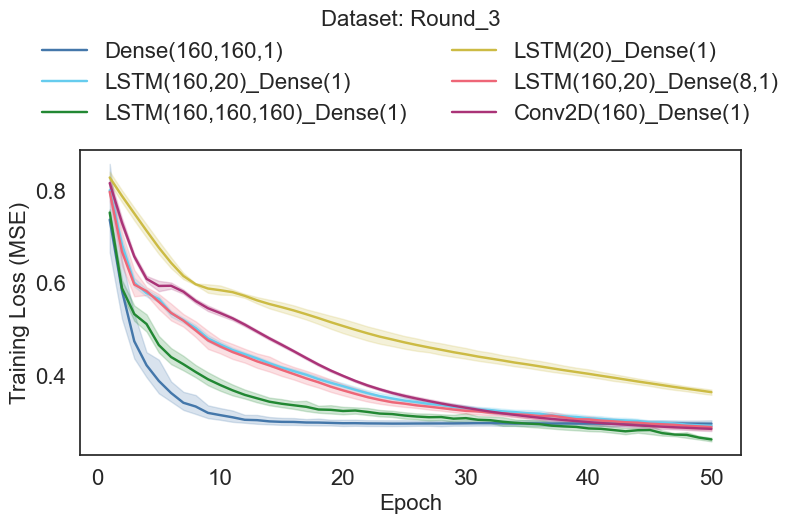

In [13]:
# Training loss plot (mean +/- 95% CI across 5 folds, per epoch) - styled to match
# figures/ModelsPerformanceTopVariants/supplementary_fig_2_training_loss.png
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
sns.set_theme(style="white")

plt.figure(figsize=(8.25, 6))
sns.lineplot(
    data=loss_plot_df,
    x='Epoch',
    y='Training Loss',
    hue='Model',
    hue_order=model_order,
    palette=palette,
    linewidth=1.75,
    errorbar=('ci', 95)
)

ax = plt.gca()
ax.set_xlabel("Epoch", fontsize=16)
ax.set_ylabel("Training Loss (MSE)", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=16,
)

# Placed above the (3-row) legend, which occupies roughly y in [1.02, 1.27]
ax.set_title("Dataset: Round_3", fontsize=16, y=1.38)

plt.tight_layout()
plt.savefig('plots/supplementary_figure_S2a_i.png')
plt.show()

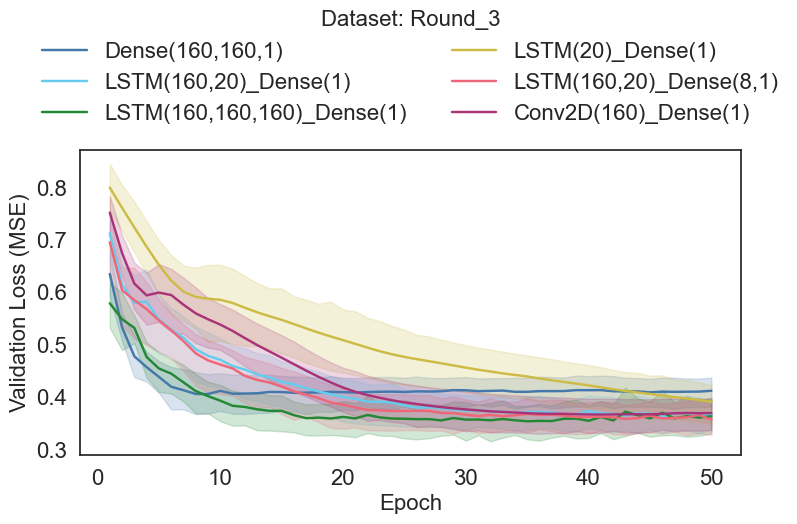

In [14]:
# Validation loss plot (mean +/- 95% CI across 5 folds, per epoch) - styled to match
# figures/ModelsPerformanceTopVariants/supplementary_fig_2_validation_loss.png
plt.figure(figsize=(8.25, 6))
sns.lineplot(
    data=loss_plot_df,
    x='Epoch',
    y='Validation Loss',
    hue='Model',
    hue_order=model_order,
    palette=palette,
    linewidth=1.75,
    errorbar=('ci', 95)
)

ax = plt.gca()
ax.set_xlabel("Epoch", fontsize=16)
ax.set_ylabel("Validation Loss (MSE)", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=16,
)

# Placed above the (3-row) legend, which occupies roughly y in [1.02, 1.27]
ax.set_title("Dataset: Round_3", fontsize=16, y=1.38)

plt.tight_layout()
plt.savefig('plots/supplementary_figure_S2a_ii.png')
plt.show()